**Setup and Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics

# Public URL for the Medical Cost dataset
dataset_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

# Load the dataset directly into a Pandas DataFrame
df = pd.read_csv(dataset_url)

# Preview the data to ensure it loaded correctly
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Data Preprocessing**


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Encoding Categorical Data
encoder = LabelEncoder()

df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])

# Define Features (X) and Target (y)
X = df.drop(columns='charges', axis=1)
y = df['charges']

# Split Data into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Data Visualization**

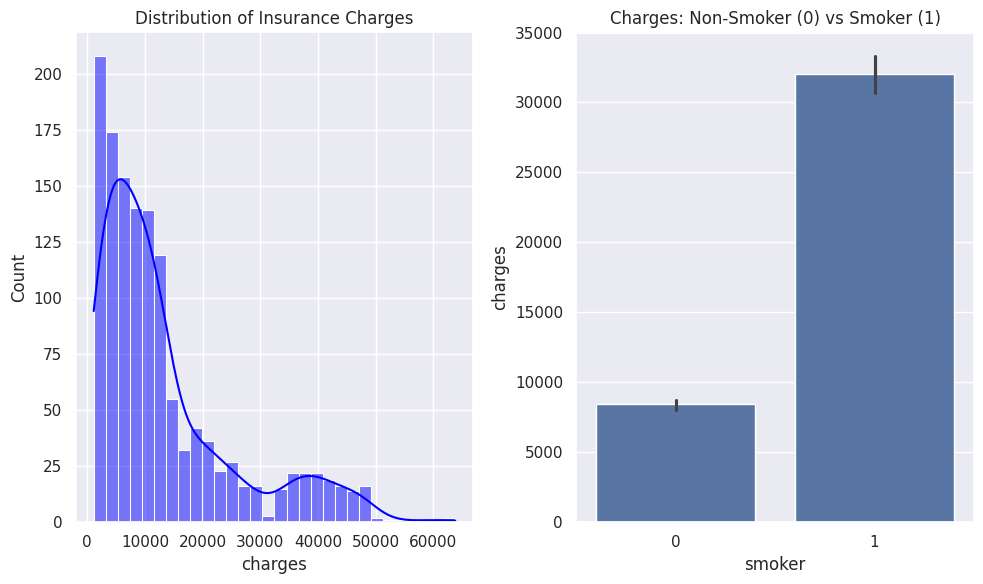

In [ ]:
sns.set()
plt.figure(figsize=(10,6))

# Distribution of Charges
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')

# Smoker vs Charges
plt.subplot(1, 2, 2)
sns.barplot(x='smoker', y='charges', data=df)
plt.title('Charges: Non-Smoker (0) vs Smoker (1)')

plt.tight_layout()
plt.show()

**Model Building and Evaluation**

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    # Evaluation Metrics
    mae = metrics.mean_absolute_error(y_test, prediction)
    r2 = metrics.r2_score(y_test, prediction)

    print(f"--- {name} ---")
    print(f"Mean Absolute Error: ${mae:.2f}")
    print(f"R² Score: {r2:.4f}\n")

--- Linear Regression ---
Mean Absolute Error: $4186.51
R² Score: 0.7833

--- Decision Tree ---
Mean Absolute Error: $2930.26
R² Score: 0.7187

--- Random Forest ---
Mean Absolute Error: $2447.47
R² Score: 0.8666



**Prediction System**

In [ ]:
# Custom User Input (Age, Sex, BMI, Children, Smoker, Region)
# Example: 31 years old, Female(0), BMI 25.7, 0 children, Non-smoker(0), Region southeast(2)
input_data = (31, 0, 25.7, 0, 0, 2)

# Convert to numpy array and reshape
input_as_numpy = np.asarray(input_data).reshape(1, -1)

# Using Random Forest (usually the most accurate of the three)
rf_model = models["Random Forest"]
prediction = rf_model.predict(input_as_numpy)

print(f"The estimated medical insurance cost is: ${prediction[0]:.2f}")

The estimated medical insurance cost is: $3794.14


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
